# Part -1

# ANN on Fashion-MNIST using PyTorch (CPU)

In this part 1, we will see:

- how to train an Artificial Neural Network (ANN) on Fashion-MNIST
- how image data can be read from a CSV file
- how to build a custom Dataset and DataLoader
- how to define a feedforward neural network in PyTorch
- how training and evaluation work
- how to measure accuracy

## 1. Problem Statement

We want to classify Fashion-MNIST images into one of 10 clothing categories.

Each image is:
- grayscale
- size 28 × 28
- flattened into 784 pixel values in the CSV file

So the model input size is 784.
The model output size is 10 because there are 10 classes.

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [23]:
df = pd.read_csv("https://raw.githubusercontent.com/SajidurCodes/Datasets/refs/heads/main/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [24]:
print("Dataset shape:", df.shape)
print("Unique labels:", sorted(df["label"].unique()))

Dataset shape: (6000, 785)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


fruits = ["Apple","banana","Mango"]

for index, fruit in enumerate(fruits):
  print(index,fruit)

## 2. Visualize Sample Images

This helps us confirm that the dataset really contains 28 × 28 fashion images.

In [25]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

- `X` contains the pixel values
- `y` contains the labels

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We use training data to learn and test data to measure performance on unseen examples.

In [27]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## 3. Why divide by 255?

Pixel values go from 0 to 255.
Dividing by 255 scales them to the range [0, 1].

This helps training become more stable.

## 4. Custom Dataset

PyTorch models usually work with tensors and dataloaders.
So we wrap our data into a custom dataset class.

In [28]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]
    


train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)



print("Train dataset length:", len(train_dataset))
print("One sample shape:", train_dataset[0][0].shape)
print("One sample label:", train_dataset[0][1])

Train dataset length: 4800
One sample shape: torch.Size([784])
One sample label: tensor(7)


In [29]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

- `batch_size=32` means the model sees 32 samples at a time
- `shuffle=True` helps training by mixing sample order

## 5. Neural Network Architecture

This network has:
- input layer: 784 features
- hidden layer 1: 128 neurons
- hidden layer 2: 64 neurons
- output layer: 10 neurons

The output has 10 values because there are 10 classes.

In [30]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, X):
        return self.model(X)

## Important Note About the Output Layer

We do **not** use `Softmax` in the final layer here because `CrossEntropyLoss`
already applies the correct internal transformation.

So the model should return raw scores, also called **logits**.

In [31]:
epochs = 10
learning_rate = 0.1

model = MyNN(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

- `CrossEntropyLoss` is used for multiclass classification
- `SGD` updates model weights using gradients

In [32]:
train_loss_history = []

for epoch in range(epochs):
    total_epoch_loss = 0

    model.train()

    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.3216
Epoch 2/10, Loss: 0.7793
Epoch 3/10, Loss: 0.6428
Epoch 4/10, Loss: 0.5752
Epoch 5/10, Loss: 0.5282
Epoch 6/10, Loss: 0.4953
Epoch 7/10, Loss: 0.4602
Epoch 8/10, Loss: 0.4359
Epoch 9/10, Loss: 0.4183
Epoch 10/10, Loss: 0.3984


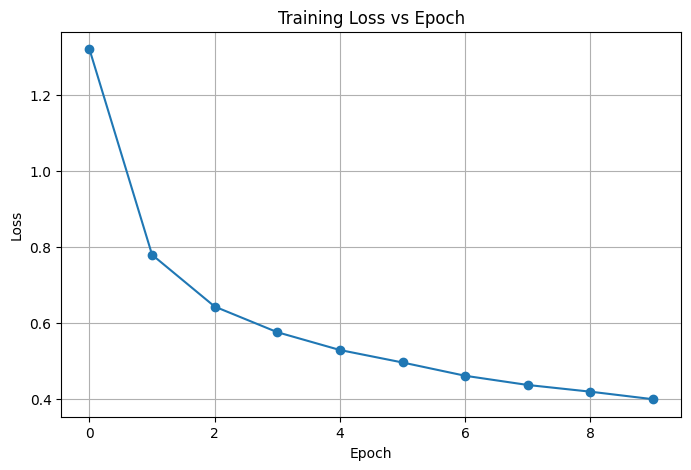

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, marker='o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [34]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8300


In [35]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

train_accuracy = correct / total
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.8640


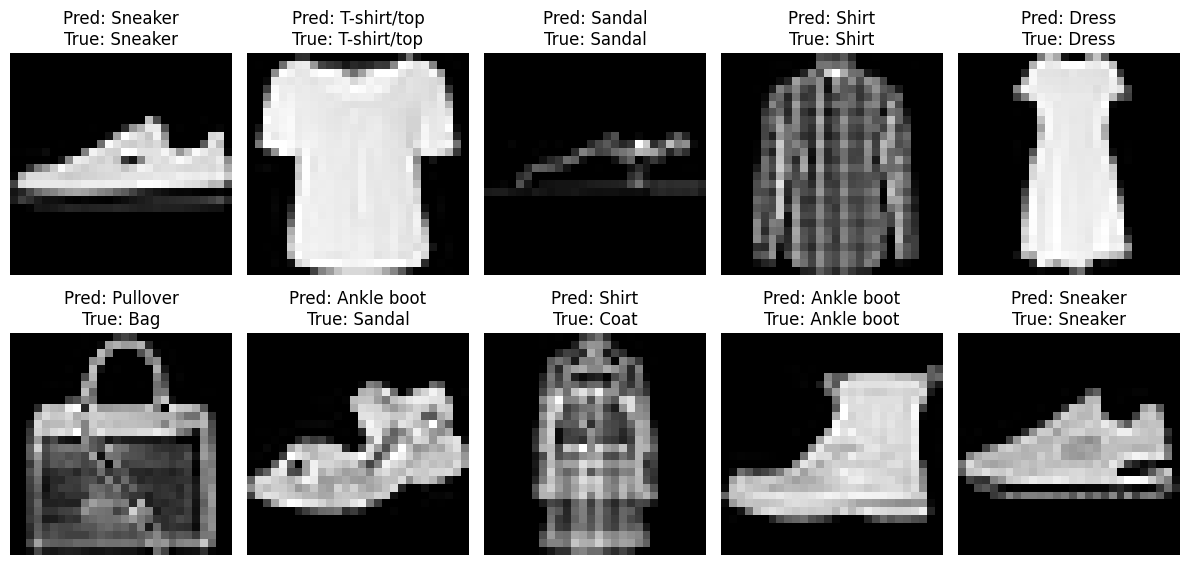

In [36]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

model.eval()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        image = X_test[i].reshape(28, 28)
        input_tensor = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0)

        outputs = model(input_tensor)
        pred = torch.argmax(outputs, dim=1).item()
        true = y_test[i]

        ax.imshow(image, cmap='gray')
        ax.set_title(f"Pred: {class_names[pred]}\nTrue: {class_names[true]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Summary

In this part 1, we covered:

- how Fashion-MNIST data can be read from a CSV file
- why normalization is important
- how to create a custom Dataset and DataLoader
- how to define an ANN using PyTorch
- how training works using forward pass, loss, backward pass, and optimizer step
- how to evaluate classification accuracy

# Part-2

# ANN on Fashion-MNIST using PyTorch (GPU)

In this notebook we will learn:

- How to train an Artificial Neural Network (ANN)
- How to classify Fashion-MNIST images
- How to use PyTorch Dataset and DataLoader
- How to train models using GPU
- How to track training loss
- How to evaluate model performance
- How to visualize predictions

## Problem Statement

Fashion-MNIST is a dataset of clothing images.

Each image:

- size: **28 × 28**
- grayscale
- flattened into **784 pixels**

The goal is to classify each image into one of **10 clothing categories**.

Examples of classes:

- T-shirt
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Therefore:

- **Input size = 784**
- **Output size = 10**

In [37]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Why use `device`?

PyTorch can run computations on:
- CPU
- GPU

If CUDA is available, we use GPU for faster matrix operations.
Otherwise, the code falls back to CPU.


## Why move model and data to the same device?

If the model is on GPU, the input data must also be on GPU.

That is why we use:
- `model.to(device)`
- `batch_features.to(device)`
- `batch_labels.to(device)`

Model and data must stay on the same device.

## What does `pin_memory=True` mean?

When using GPU, `pin_memory=True` can make CPU-to-GPU data transfer more efficient.

It is useful mainly when CUDA is available.


## CPU vs GPU

The model logic is the same in both notebooks.

The main difference is:
- CPU notebook keeps everything on CPU
- GPU notebook moves model and batches to GPU

This becomes especially useful for larger datasets and bigger models.

In [38]:
df = pd.read_csv("https://raw.githubusercontent.com/SajidurCodes/Datasets/refs/heads/main/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [39]:
print("Dataset shape:", df.shape)
print("Unique labels:", sorted(df["label"].unique()))

Dataset shape: (6000, 785)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


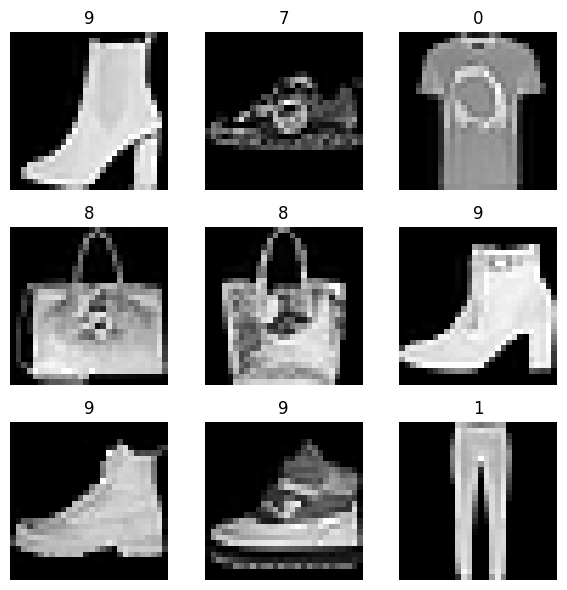

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    image = df.iloc[i,1:].values.reshape(28,28)
    label = df.iloc[i,0]

    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training data → used for learning  
Test data → used for evaluation

In [43]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Pixel values range from **0 to 255**.

Dividing by 255 scales them to **0–1**, which helps neural networks train more efficiently.

In [44]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [45]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [46]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

DataLoader provides:

- batching
- shuffling
- efficient data loading

In [47]:
class MyNN(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)

The final layer does NOT use Softmax because `CrossEntropyLoss`
already applies the correct internal transformation.

The model outputs **logits**, not probabilities.

In [48]:
model = MyNN(X_train.shape[1]).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 10


train_loss_history = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 Loss: 1.3216
Epoch 2/10 Loss: 0.7793
Epoch 3/10 Loss: 0.6428
Epoch 4/10 Loss: 0.5752
Epoch 5/10 Loss: 0.5282
Epoch 6/10 Loss: 0.4953
Epoch 7/10 Loss: 0.4602
Epoch 8/10 Loss: 0.4359
Epoch 9/10 Loss: 0.4183
Epoch 10/10 Loss: 0.3984


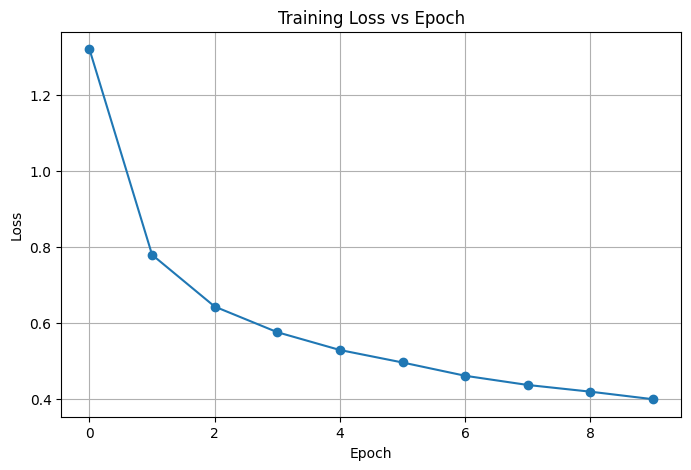

In [49]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, marker='o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [50]:
model.eval()

total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)

        _, predicted = torch.max(outputs,1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

test_accuracy = correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.83


In [51]:
model.eval()

total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)

        _, predicted = torch.max(outputs,1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

train_accuracy = correct / total

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.8639583333333334


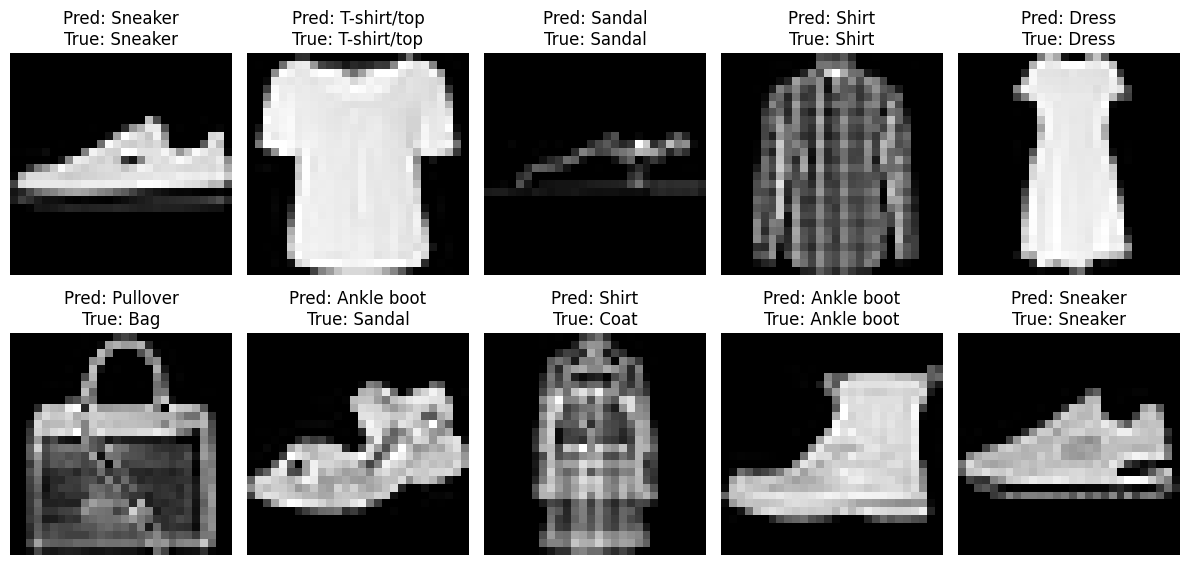

In [52]:
class_names = [
"T-shirt/top","Trouser","Pullover","Dress","Coat",
"Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

model.eval()

fig, axes = plt.subplots(2,5, figsize=(12,6))

with torch.no_grad():

    for i, ax in enumerate(axes.flat):

        image = X_test[i].reshape(28,28)

        input_tensor = torch.tensor(X_test[i],dtype=torch.float32).unsqueeze(0).to(device)

        outputs = model(input_tensor)

        pred = torch.argmax(outputs,dim=1).item()

        true = y_test[i]

        ax.imshow(image,cmap='gray')
        ax.set_title(f"Pred: {class_names[pred]}\nTrue: {class_names[true]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Observations

If training accuracy >> test accuracy  
→ model may be **overfitting**

If both accuracies are low  
→ model may be **underfitting**

Possible improvements:

- increase training epochs
- increase dataset size
- adjust learning rate
- add regularization


## Summary

In this part we learned:

- How to classify Fashion-MNIST images
- How to build an ANN in PyTorch
- How Dataset and DataLoader work
- How to train a neural network
- How to move models and tensors to GPU
- How to evaluate classification accuracy
- How to visualize model predictions